<a href="https://colab.research.google.com/github/narayananxyz/deep_learning/blob/main/simple_digit_training_using_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load tensorflow
And print the version

In [1]:
import tensorflow as tf
tf.__version__

'2.20.0'

# Import Dataset

The MNIST (Modified National Institute of Standards and Technology) dataset is a foundational database of 70,000 handwritten digits used to train and test machine learning and computer vision systems. Widely considered the "Hello World" of machine learning, it is primarily used for image classification benchmarking

In [2]:
mnist = tf.keras.datasets.mnist

# Load Dataset

There is a nice function load the dataset. It already does a 1:6 split. In this case we have 70k records, and we put 10k records aside for testing

In [3]:
(x_train, y_train),(x_test, y_test) = mnist.load_data()

print(f"Total records: {len(x_train) + len(x_test)}")
print(f"Training records: {len(x_train)}")
print(f"Test records: {len(x_test)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total records: 70000
Training records: 60000
Test records: 10000


# Look at sample data

Let's look at the data. In this case the data is image so we can use matplotlib to visualize the image.

If you see that every record has a image and a label. we are doing supervised learning. hence we are using labelled data set. We are looking a ramdom 6 images to visualize

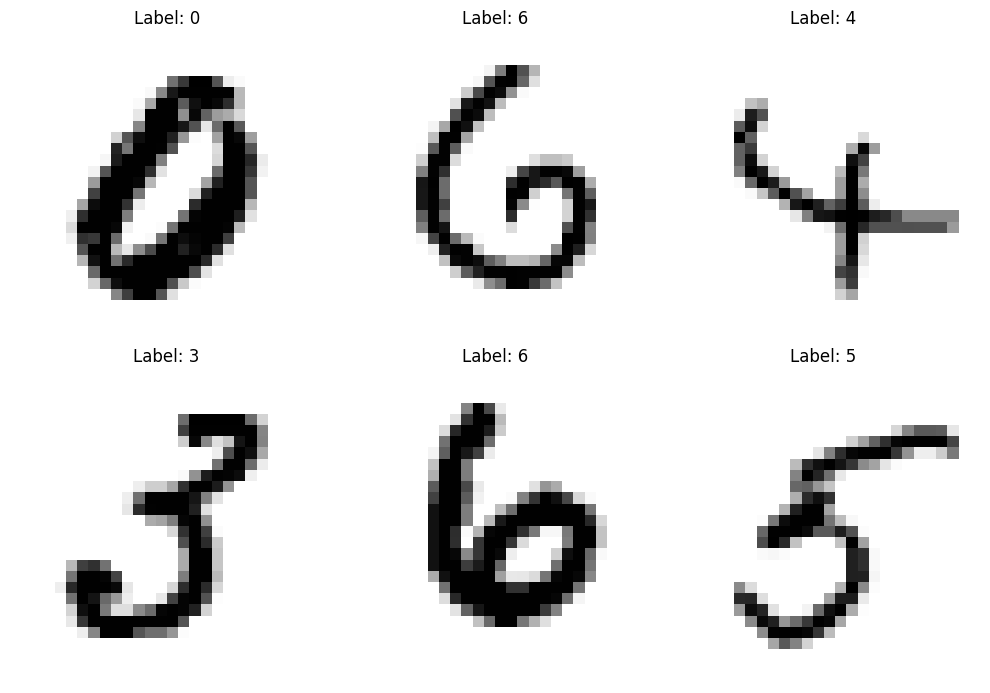

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Generate 6 random indices
random_indices = np.random.choice(len(x_train), 6, replace=False)

plt.figure(figsize=(10, 7)) # Adjust figure size for 6 images

for i, index in enumerate(random_indices):
    plt.subplot(2, 3, i + 1) # 2 rows, 3 columns, plot index i+1
    plt.imshow(x_train[index], cmap=plt.cm.binary)
    plt.title(f"Label: {y_train[index]}")
    plt.axis('off') # Hide axes for cleaner image display

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

Let's look at the image as an array.

In [8]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

def highlight_greater_than_zero(val):
    return 'background-color: yellow' if val > 0 else ''

df_image = pd.DataFrame(x_train[7])
display(df_image.style.map(highlight_greater_than_zero))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,38,43,105,255,253,253,253,253,253,174,6,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,43,139,224,226,252,253,252,252,252,252,252,252,158,14,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,178,252,252,252,252,253,252,252,252,252,252,252,252,59,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,109,252,252,230,132,133,132,132,189,252,252,252,252,59,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,4,29,29,24,0,0,0,0,14,226,252,252,172,7,0,0,0,0,0


# Normalization

We normalize this so that cnn can perform better. you can try skipping this and see how it works.

In [9]:
x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test, axis=1)

In [10]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

def highlight_greater_than_zero(val):
    return 'background-color: yellow' if val > 0 else ''

df_image = pd.DataFrame(x_train[7])
display(df_image.style.map(highlight_greater_than_zero).format(precision=2))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.06,0.15,0.34,0.32,0.30,0.27,0.26,0.34,0.26,0.01,0.00,0.00,0.00,0.00,0.00,0.00
6,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.07,0.20,0.32,0.33,0.37,0.33,0.32,0.30,0.27,0.26,0.34,0.37,0.35,0.16,0.00,0.00,0.00,0.00,0.00
7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.30,0.36,0.36,0.37,0.37,0.33,0.32,0.30,0.27,0.26,0.34,0.37,0.56,0.69,0.00,0.00,0.00,0.00,0.00
8,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.18,0.36,0.36,0.34,0.19,0.18,0.17,0.16,0.20,0.26,0.34,0.37,0.56,0.69,0.00,0.00,0.00,0.00,0.00
9,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.04,0.04,0.04,0.00,0.00,0.00,0.00,0.01,0.23,0.34,0.37,0.38,0.08,0.00,0.00,0.00,0.00,0.00


# Build the model

Let's build the model.

In [49]:
model = tf.keras.models.Sequential()
# This is the first layer. Flatten because we are sending one long array.
model.add(tf.keras.layers.Flatten())
# This is one hidden layer
model.add(tf.keras.layers.Dense(128, activation='relu'))
# This is another hidden layer
model.add(tf.keras.layers.Dense(128, activation='relu'))
# This is another hidden layer
model.add(tf.keras.layers.Dense(128, activation='relu'))
# This the output layer. since we are classifying digits.
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model

In [50]:
model.fit(x_train, y_train, epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9245 - loss: 0.2534
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9675 - loss: 0.1068
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9760 - loss: 0.0753


# Test the model

Remember we had test data befoere. we can use that to evaluate the model

In [51]:
val_loss, val_acc = model.evaluate(x_test, y_test)
print(val_loss)
print(val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9696 - loss: 0.0965
0.0965287908911705
0.9696000218391418


# A Practical Test

Original label for this image (from y_test): 0


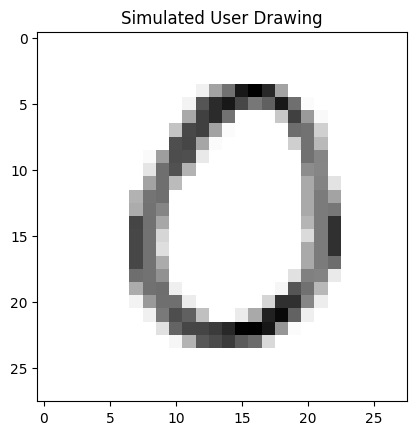

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
Model predicted: 0
Confidence: 99.99%


In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Choose an image from the test set to simulate a 'user drawing'
# We are using x_test[0], which corresponds to the digit 7
image_index = 750
drawn_image = x_test[image_index] # This image is already normalized

# Display the "drawn" image
print(f"Original label for this image (from y_test): {y_test[image_index]}")
plt.imshow(drawn_image, cmap=plt.cm.binary)
plt.title("Simulated User Drawing")
plt.show()

# Reshape the image for the model: add a batch dimension
# The model expects input shape (batch_size, 28, 28)
processed_image = np.expand_dims(drawn_image, axis=0)

# Get the model's prediction
predictions = model.predict(processed_image)

# The predictions are probabilities for each digit (0-9)
# Find the digit with the highest probability
predicted_digit = np.argmax(predictions[0])
confidence = predictions[0][predicted_digit] * 100

print(f"Model predicted: {predicted_digit}")
print(f"Confidence: {confidence:.2f}%")

# Optionally, show all probabilities for detailed analysis
# print("\nProbabilities for each digit:")
# for i, prob in enumerate(predictions[0]):
#     print(f"Digit {i}: {prob*100:.2f}%")

# Loading and saving models

We generally save our model to re-load and predict again.

In [53]:
model.save('mnist_model_ng22.h5')

In [54]:
model_new = tf.keras.models.load_model('mnist_model_ng22.h5')

In [55]:
val_loss, val_acc = model_new.evaluate(x_test, y_test)
print(val_loss)
print(val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9696 - loss: 0.0965
0.0965287908911705
0.9696000218391418
